In [1]:
%load_ext autoreload
%autoreload 2

In [12]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import torch
from tqdm import tqdm 
from examples.cmhe_demo_utils import * 
from metrics import treatment_effect

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:994: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'PRIMARY': outcomedt = 'PRIMRYDT'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1174: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'EP_CHD': outcomedt = 'DYCHD'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1175: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif outcome is 'CANCER': outcomedt = 'DYCANC'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1176: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif outcome is 'GIBLEED': outcomedt = 'DYGIBLD'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospe

In [16]:
from datasets_retrospective import load_best_dataset
outcomes, features, intervention = load_best_dataset(location='datasets/', outcome='MOCAUSE')

(34045, 5)
(2707, 1)


In [8]:
features

,Baseline_Heart_Rate,Baseline_Height_CM,Baseline_Seated_Diastolic_Blood_Pressure,Baseline_Weight_KG,Baseline_Seated_Systolic_Blood_Pressure
BEST_ID,,,,,
5.0,71.0,165.10,71.0,69.75,133.0
5.0,72.0,152.40,69.0,69.30,122.0
5.0,75.0,152.40,66.0,70.20,127.0
5.0,76.0,152.40,59.0,71.55,113.0
5.0,79.0,152.40,61.0,70.65,107.0
...,...,...,...,...,...
2708.0,90.0,147.32,60.0,115.65,95.0
2708.0,98.0,147.32,75.0,115.65,119.0
2708.0,107.0,147.32,80.0,115.20,114.0


In [17]:
outcomes

,time,event
BEST_ID,,
5.0,650.0,False
5.0,650.0,False
5.0,650.0,False
5.0,650.0,False
5.0,650.0,False
...,...,...
2708.0,222.0,True
2708.0,222.0,True
2708.0,222.0,True


In [18]:
from auton_survival import reporting

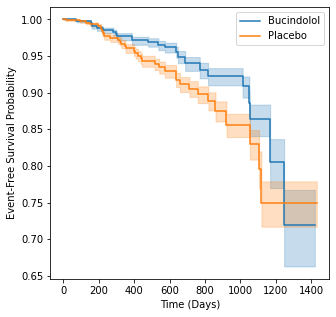

In [19]:
# Let's plot the survival curves in the original paper
plt.figure(figsize=(5,5))
ax_0 = reporting.plot_kaplanmeier(outcomes, intervention)
h, l = ax_0.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Bucindolol', 'Placebo'], loc="upper right")
plt.show()
pass

In [10]:
sum(outcomes.event)

1297

In [2]:
from datasets_retrospective import load_cardia_dataset
outcomes, features, cat_feats, num_feats = load_cardia_dataset(location='datasets/', outcome='DEATH')

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:994: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'PRIMARY': outcomedt = 'PRIMRYDT'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1174: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'EP_CHD': outcomedt = 'DYCHD'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1175: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif outcome is 'CANCER': outcomedt = 'DYCANC'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1176: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif outcome is 'GIBLEED': outcomedt = 'DYGIBLD'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospe

(5113, 4)
(5113, 2)
(5113, 4)
(5113, 2)
(5113, 3)
(5113, 1)


In [3]:
features

,Sex,Baseline_Total_Cholesterol,Baseline_Age,Baseline_Weight_KG,Baseline_BMI,Baseline_LDL_Cholesterol,Race,Baseline_Seated_Diastolic_Blood_Pressure,Baseline_Smoke_Status,Baseline_Serum_creatinine,Baseline_Triglycerides,Baseline_HDL_Cholesterol,Baseline_Glucose,Baseline_Seated_Systolic_Blood_Pressure,Baseline_Height_CM,Baseline_History_Diabetes
PID,,,,,,,,,,,,,,,,
174.0,Male,214.0,30.0,67.32,23.668433,143.0,Black,59.0,0.0,1.0,78.0,55.0,85.0,96.0,169.5,No
245.0,Female,215.0,23.0,55.89,19.082797,128.0,White,69.0,0.0,0.8,110.0,65.0,83.0,106.0,172.0,No
402.0,Female,185.0,25.0,68.40,27.158109,121.0,White,71.0,Yes,0.9,81.0,47.0,80.0,111.0,159.5,No
769.0,Male,160.0,28.0,65.88,20.538721,80.0,Black,66.0,0.0,1.3,45.0,72.0,87.0,119.0,180.0,No
820.0,Male,228.0,29.0,96.30,30.529146,166.0,Black,80.0,Yes,1.3,120.0,38.0,89.0,131.0,178.5,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998746.0,Female,149.0,27.0,55.35,19.691673,79.0,White,66.0,0.0,1.1,34.0,63.0,83.0,100.0,168.5,No
999199.0,Male,147.0,22.0,60.75,19.923097,73.0,White,65.0,0.0,1.0,111.0,52.0,73.0,96.0,175.5,No
999202.0,Male,183.0,29.0,67.59,19.948204,133.0,White,82.0,0.0,1.1,47.0,41.0,76.0,116.0,185.0,No


In [6]:
sum(outcomes.event)

509

In [2]:
from datasets_retrospective import load_sprint_dataset
outcomes, features, intervention, cat_feats, num_feats = load_sprint_dataset(location='datasets/', outcome='PRIMARY')

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:990: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'PRIMARY': outcomedt = 'PRIMRYDT'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1170: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'EP_CHD': outcomedt = 'DYCHD'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1171: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif outcome is 'CANCER': outcomedt = 'DYCANC'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1172: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif outcome is 'GIBLEED': outcomedt = 'DYGIBLD'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospe

(9361, 27)
(6646, 2)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:119: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intervention[intervention == 1.0] = 'SBP target <120mm Hg'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:119: SettingWithCopyWar

In [3]:
features

,Baseline_Weight_LBS,Baseline_>75_years_old,Baseline_Total_Cholesterol,Baseline_History_Clinical_Cardiovascular_Disease,Baseline_On_no_anti-hypertensive_agents,Baseline_HDL_Cholesterol,Baseline_Estimation_10-year_Casdiovascular_disease_risk,Race,Baseline_On_Statin,Baseline_History_Cardiovascular_Disease,...,Baseline_Estimated_Glomerular_Filtration_Rate,Baseline_Seated_Diastolic_Blood_Pressure,Baseline_Seated_Systolic_Blood_Pressure,Baseline_Glucose,Baseline_BMI,Baseline_Number_medications_prescribed,Baseline_Smoke_status,Baseline_10-year_Casdiovascular_disease_risk>15%,Baseline_History_Aspirin,Baseline_Height_INC
S00007,199.0,No,155.0,Yes,One or more,36.0,29.732061,WHITE,Yes,Yes,...,67.69,80.0,145.0,81.0,33.115201,2.0,Current,Yes,Yes,65.0
S00010,NaN,Yes,243.0,No,One or more,61.0,29.677619,WHITE,Yes,No,...,60.64,71.0,138.0,107.0,28.842380,1.0,Former,Yes,Yes,NaN
S00022,140.5,No,232.0,No,One or more,53.0,9.597287,HISPANIC,Yes,No,...,85.09,84.0,144.0,95.0,24.888358,3.0,Never,No,No,63.0
S00038,255.0,No,180.0,No,One or more,47.0,17.443819,WHITE,No,No,...,68.44,92.0,143.0,116.0,33.643060,2.0,Former,Yes,No,73.0
S00045,NaN,Yes,234.0,No,One or more,89.0,8.627849,WHITE,No,No,...,71.94,68.0,123.0,93.0,29.337871,2.0,Never,No,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S99969,NaN,Yes,199.0,No,One or more,85.0,10.896486,WHITE,Yes,No,...,79.57,59.0,138.0,90.0,27.186534,2.0,Former,No,Yes,NaN
S99974,NaN,Yes,145.0,No,One or more,52.0,8.646088,WHITE,Yes,No,...,22.60,73.0,119.0,83.0,42.191997,3.0,Former,No,No,NaN
S99983,143.5,No,167.0,Yes,On no agents,46.0,24.191491,WHITE,Yes,Yes,...,74.74,75.0,137.0,80.0,19.462021,0.0,Former,Yes,No,72.0
S99992,234.0,No,245.0,No,On no agents,37.0,20.354619,WHITE,No,No,...,32.32,93.0,154.0,103.0,35.579436,0.0,Former,Yes,Yes,68.0


In [4]:
interventions = intervention[features.index]

In [5]:
from sklearn.model_selection import train_test_split

# Split the SPRINT data into training, validation, and test data
x_tr, x_te, y_tr, y_te = train_test_split(features, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(interventions=='Niacin'))

print(f'Number of training data points: {len(x_tr)}')
print(f'Number of test data points: {len(x_te)}')

Number of training data points: 2389
Number of test data points: 1025


In [6]:
from preprocessing import Preprocessor

# Fit the imputer and scaler to the training data and transform the training, validation and test data
preprocessor = Preprocessor(cat_feat_strat='ignore', num_feat_strat= 'mean') 
transformer = preprocessor.fit(features, cat_feats=cat_feats, num_feats=num_feats,
                                one_hot=True, fill_value=-1)
x_tr = transformer.transform(x_tr)
x_te = transformer.transform(x_te)

In [11]:
from auton_survival.estimators import SurvivalModel
from auton_survival.metrics import survival_regression_metric
from sklearn.model_selection import ParameterGrid

# Define parameters for tuning the model
param_grid = {'bs' : [256],
              'learning_rate' : [ 1e-3]
             }

params = ParameterGrid(param_grid)

# Define the times for tuning the model hyperparameters and for evaluating the model
times = [1.0*365.25, 2.0*365.25, 3.0*365.25, 4.0*365.25]

# Perform hyperparameter tuning 
models = []
for param in params:
    model = SurvivalModel('dcph', layers=[], random_seed=0, bs=param['bs'], learning_rate=param['learning_rate'], epochs=100)
    
    # The fit method is called to train the model
    model.fit(x_tr, y_tr)
    

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 42%|████▏     | 42/100 [00:01<00:01, 29.44it/s]


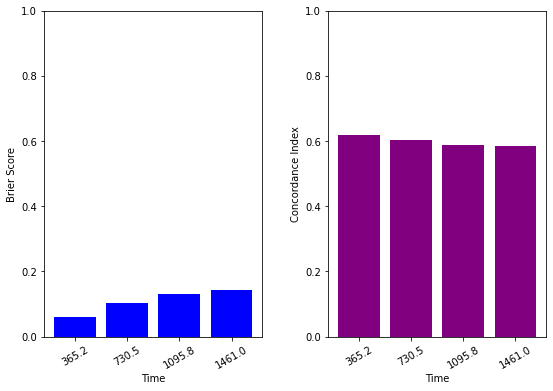

In [12]:
from examples.estimators_demo_utils import plot_performance_metrics
import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
# Obtain survival probabilities for test set
predictions_te = model.predict_survival(x_te, times)

# Compute the Brier Score and time-dependent concordance index for the test set to assess model performance
results = dict()
results['Brier Score'] = survival_regression_metric('brs', outcomes=y_te, predictions=predictions_te, 
                                                    times=times, outcomes_train=y_tr)
results['Concordance Index'] = survival_regression_metric('ctd', outcomes=y_te, predictions=predictions_te, 
                                                    times=times, outcomes_train=y_tr)
plot_performance_metrics(results, times)

In [10]:
from datasets_retrospective import load_oat_dataset
outcomes, features, intervention, cat_feats, num_feats = load_oat_dataset(location='datasets/OAT/Ancillary/', outcome='comb')

(2166, 52)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:357: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intervention[intervention == '1'] = 'Percutaneous coronary intervention'


In [11]:
from sklearn.model_selection import train_test_split

# Split the SPRINT data into training, validation, and test data
x_tr, x_te, y_tr, y_te = train_test_split(features, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(intervention=='Percutaneous coronary intervention'))

print(f'Number of training data points: {len(x_tr)}')
print(f'Number of test data points: {len(x_te)}')

Number of training data points: 1516
Number of test data points: 650


In [16]:
from auton_survival.preprocessing import Preprocessor

# Fit the imputer and scaler to the training data and transform the training, validation and test data
preprocessor = Preprocessor(cat_feat_strat='ignore', num_feat_strat= 'mean') 
transformer = preprocessor.fit(features, cat_feats=cat_feats, num_feats=num_feats,
                                one_hot=True, fill_value=-1)
x_tr = transformer.transform(x_tr)
x_te = transformer.transform(x_te)

In [17]:
from auton_survival.estimators import SurvivalModel
from auton_survival.metrics import survival_regression_metric
from sklearn.model_selection import ParameterGrid

# Define parameters for tuning the model
param_grid = {'bs' : [256],
              'learning_rate' : [ 1e-3]
             }

params = ParameterGrid(param_grid)

# Define the times for tuning the model hyperparameters and for evaluating the model
times = [1.0*365.25, 2.0*365.25, 3.0*365.25, 4.0*365.25]

# Perform hyperparameter tuning 
models = []
for param in params:
    model = SurvivalModel('dcph', layers=[], random_seed=0, bs=param['bs'], learning_rate=param['learning_rate'], epochs=100)
    
    # The fit method is called to train the model
    model.fit(x_tr, y_tr)
    

100%|██████████| 100/100 [00:02<00:00, 48.16it/s]


In [18]:
from examples.estimators_demo_utils import plot_performance_metrics
import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
# Obtain survival probabilities for test set
predictions_te = model.predict_survival(x_te, times)

# Compute the Brier Score and time-dependent concordance index for the test set to assess model performance
results = dict()
results['Brier Score'] = survival_regression_metric('brs', outcomes=y_te, predictions=predictions_te, 
                                                    times=times, outcomes_train=y_tr)
results['Concordance Index'] = survival_regression_metric('ctd', outcomes=y_te, predictions=predictions_te, 
                                                    times=times, outcomes_train=y_tr)
plot_performance_metrics(results, times)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (650x57 and 58x1)

<Figure size 648x432 with 0 Axes>

In [4]:
from datasets_retrospective import load_peace_dataset
outcomes, features, intervention, cat_feats, num_feats = load_peace_dataset(location='datasets/PEACE/Data/', outcome='PRIMARY')

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:955: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'PRIMARY': outcomedt = 'PRIMRYDT'


(8290, 7)
(8290, 39)
(8290, 7)
(8290, 39)


In [5]:
from sklearn.model_selection import train_test_split

# Split the SPRINT data into training, validation, and test data
x_tr, x_te, y_tr, y_te = train_test_split(features, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(intervention=='Trandolapril'))

print(f'Number of training data points: {len(x_tr)}')
print(f'Number of test data points: {len(x_te)}')

Number of training data points: 5803
Number of test data points: 2487


In [7]:
from auton_survival.preprocessing import Preprocessor

# Fit the imputer and scaler to the training data and transform the training, validation and test data
preprocessor = Preprocessor(cat_feat_strat='ignore', num_feat_strat= 'mean') 
transformer = preprocessor.fit(features, cat_feats=cat_feats, num_feats=num_feats,
                                one_hot=True, fill_value=-1)
x_tr = transformer.transform(x_tr)
x_te = transformer.transform(x_te)

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
from auton_survival.estimators import SurvivalModel
from auton_survival.metrics import survival_regression_metric
from sklearn.model_selection import ParameterGrid

# Define parameters for tuning the model
param_grid = {'bs' : [256],
              'learning_rate' : [ 1e-3]
             }

params = ParameterGrid(param_grid)

# Define the times for tuning the model hyperparameters and for evaluating the model
times = [1.0*365.25, 2.0*365.25, 3.0*365.25, 4.0*365.25]

# Perform hyperparameter tuning 
models = []
for param in params:
    model = SurvivalModel('dcph', layers=[], random_seed=0, bs=param['bs'], learning_rate=param['learning_rate'], epochs=100)
    
    # The fit method is called to train the model
    model.fit(x_tr, y_tr)

 48%|████▊     | 48/100 [00:03<00:04, 12.77it/s]


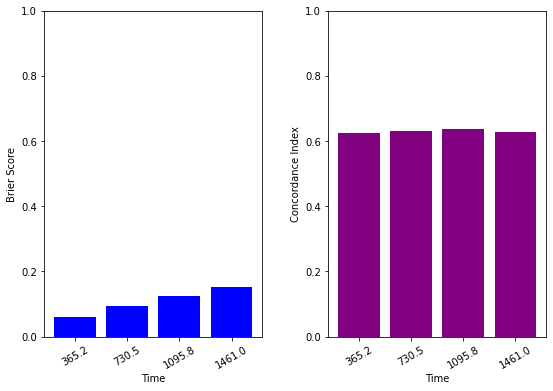

In [9]:
from examples.estimators_demo_utils import plot_performance_metrics
import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
# Obtain survival probabilities for test set
predictions_te = model.predict_survival(x_te, times)

# Compute the Brier Score and time-dependent concordance index for the test set to assess model performance
results = dict()
results['Brier Score'] = survival_regression_metric('brs', outcomes=y_te, predictions=predictions_te, 
                                                    times=times, outcomes_train=y_tr)
results['Concordance Index'] = survival_regression_metric('ctd', outcomes=y_te, predictions=predictions_te, 
                                                    times=times, outcomes_train=y_tr)
plot_performance_metrics(results, times)

In [2]:
from datasets_retrospective import load_accord_dataset
outcomes, features, intervention, cat_feats, num_feats = load_accord_dataset(location='datasets/ACCORD/')

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:955: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'PRIMARY': outcomedt = 'PRIMRYDT'


No Features Specified!! using default baseline features.
(10251, 5)
(10205, 3)
(10251, 21)
(10197, 5)
(10240, 9)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:737: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes['event'] = 1-outcomes['event']
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_re

In [12]:
from sklearn.model_selection import train_test_split

# Split the SPRINT data into training, validation, and test data
x_tr, x_te, y_tr, y_te = train_test_split(features, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(intervention=='Early Revascularization'))

print(f'Number of training data points: {len(x_tr)}')
print(f'Number of test data points: {len(x_te)}')

Number of training data points: 1657
Number of test data points: 711


In [13]:
from auton_survival.preprocessing import Preprocessor

# Fit the imputer and scaler to the training data and transform the training, validation and test data
preprocessor = Preprocessor(cat_feat_strat='ignore', num_feat_strat= 'mean') 
transformer = preprocessor.fit(features, cat_feats=cat_feats, num_feats=num_feats,
                                one_hot=True, fill_value=-1)
x_tr = transformer.transform(x_tr)
x_te = transformer.transform(x_te)

In [14]:
from auton_survival.estimators import SurvivalModel
from auton_survival.metrics import survival_regression_metric
from sklearn.model_selection import ParameterGrid

# Define parameters for tuning the model
param_grid = {'bs' : [256],
              'learning_rate' : [ 1e-3]
             }

params = ParameterGrid(param_grid)

# Define the times for tuning the model hyperparameters and for evaluating the model
times = [1.0*365.25, 2.0*365.25, 3.0*365.25, 4.0*365.25]

# Perform hyperparameter tuning 
models = []
for param in params:
    model = SurvivalModel('dcph', layers=[], random_seed=0, bs=param['bs'], learning_rate=param['learning_rate'], epochs=100)
    
    # The fit method is called to train the model
    model.fit(x_tr, y_tr)

 71%|███████   | 71/100 [00:01<00:00, 44.95it/s]


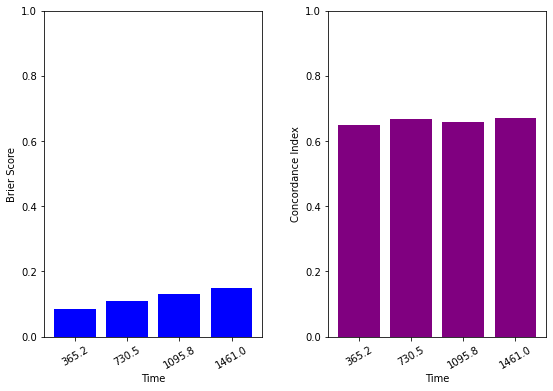

In [15]:
from examples.estimators_demo_utils import plot_performance_metrics
import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
# Obtain survival probabilities for test set
predictions_te = model.predict_survival(x_te, times)

# Compute the Brier Score and time-dependent concordance index for the test set to assess model performance
results = dict()
results['Brier Score'] = survival_regression_metric('brs', outcomes=y_te, predictions=predictions_te, 
                                                    times=times, outcomes_train=y_tr)
results['Concordance Index'] = survival_regression_metric('ctd', outcomes=y_te, predictions=predictions_te, 
                                                    times=times, outcomes_train=y_tr)
plot_performance_metrics(results, times)

In [7]:
from datasets_retrospective import load_bari_2d_dataset
outcomes, features, intervention, cat_feats, num_feats = load_bari_2d_dataset(location='datasets/')

(2368, 48)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)


In [8]:
from sklearn.model_selection import train_test_split

# Split the SPRINT data into training, validation, and test data
x_tr, x_te, y_tr, y_te = train_test_split(features, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(intervention=='SBP target <120mm Hg'))

print(f'Number of training data points: {len(x_tr)}')
print(f'Number of test data points: {len(x_te)}')

Number of training data points: 1657
Number of test data points: 711


In [9]:
from auton_survival.preprocessing import Preprocessor

# Fit the imputer and scaler to the training data and transform the training, validation and test data
preprocessor = Preprocessor(cat_feat_strat='ignore', num_feat_strat= 'mean') 
transformer = preprocessor.fit(features, cat_feats=cat_feats, num_feats=num_feats,
                                one_hot=True, fill_value=-1)
x_tr = transformer.transform(x_tr)
x_te = transformer.transform(x_te)

In [10]:
from auton_survival.estimators import SurvivalModel
from auton_survival.metrics import survival_regression_metric
from sklearn.model_selection import ParameterGrid

# Define parameters for tuning the model
param_grid = {'bs' : [256],
              'learning_rate' : [ 1e-3]
             }

params = ParameterGrid(param_grid)

# Define the times for tuning the model hyperparameters and for evaluating the model
times = [1.0*365.25, 2.0*365.25, 3.0*365.25, 4.0*365.25]

# Perform hyperparameter tuning 
models = []
for param in params:
    model = SurvivalModel('dcph', layers=[], random_seed=0, bs=param['bs'], learning_rate=param['learning_rate'], epochs=100)
    
    # The fit method is called to train the model
    model.fit(x_tr, y_tr)
    

 82%|████████▏ | 82/100 [00:01<00:00, 42.46it/s]


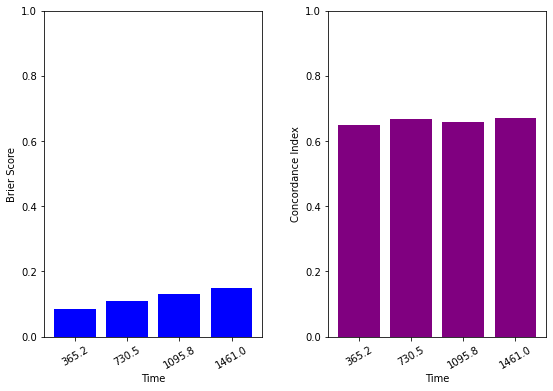

In [16]:
from examples.estimators_demo_utils import plot_performance_metrics
import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
# Obtain survival probabilities for test set
predictions_te = model.predict_survival(x_te, times)

# Compute the Brier Score and time-dependent concordance index for the test set to assess model performance
results = dict()
results['Brier Score'] = survival_regression_metric('brs', outcomes=y_te, predictions=predictions_te, 
                                                    times=times, outcomes_train=y_tr)
results['Concordance Index'] = survival_regression_metric('ctd', outcomes=y_te, predictions=predictions_te, 
                                                    times=times, outcomes_train=y_tr)
plot_performance_metrics(results, times)

In [ ]:
from datasets_retrospective import load_accord_dataset
outcomes, features, intervention, cat_feats, num_feats = load_accord_dataset(location='datasets/ACCORD/', intervention='Lipid')

In [17]:
from sklearn.model_selection import train_test_split

# Split the SPRINT data into training, validation, and test data
x_tr, x_te, y_tr, y_te = train_test_split(features, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(intervention=='Lipid Fibrate'))

print(f'Number of training data points: {len(x_tr)}')
print(f'Number of test data points: {len(x_te)}')

Number of training data points: 1657
Number of test data points: 711


In [18]:
from auton_survival.preprocessing import Preprocessor

# Fit the imputer and scaler to the training data and transform the training, validation and test data
preprocessor = Preprocessor(cat_feat_strat='ignore', num_feat_strat= 'mean') 
transformer = preprocessor.fit(features, cat_feats=cat_feats, num_feats=num_feats,
                                one_hot=True, fill_value=-1)
x_tr = transformer.transform(x_tr)
x_te = transformer.transform(x_te)

In [23]:
from auton_survival.estimators import SurvivalModel
from auton_survival.metrics import survival_regression_metric
from sklearn.model_selection import ParameterGrid

# Define parameters for tuning the model
param_grid = {'bs' : [256],
              'learning_rate' : [ 1e-3]
             }

params = ParameterGrid(param_grid)

# Define the times for tuning the model hyperparameters and for evaluating the model
times = [1.0*365.25, 2.0*365.25, 3.0*365.25, 4.0*365.25, 5.0*365.25, 6.0*365.25, 7.0*365.25]

# Perform hyperparameter tuning 
models = []
for param in params:
    model = SurvivalModel('dcph', layers=[], random_seed=0, bs=param['bs'], learning_rate=param['learning_rate'], epochs=100)
    
    # The fit method is called to train the model
    model.fit(x_tr, y_tr)
    

 82%|████████▏ | 82/100 [00:01<00:00, 44.62it/s]


In [24]:
from examples.estimators_demo_utils import plot_performance_metrics
import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
# Obtain survival probabilities for test set
predictions_te = model.predict_survival(x_te, times)

# Compute the Brier Score and time-dependent concordance index for the test set to assess model performance
results = dict()
results['Brier Score'] = survival_regression_metric('brs', outcomes=y_te, predictions=predictions_te, 
                                                    times=times, outcomes_train=y_tr)
results['Concordance Index'] = survival_regression_metric('ctd', outcomes=y_te, predictions=predictions_te, 
                                                    times=times, outcomes_train=y_tr)
plot_performance_metrics(results, times)

ValueError: time must be smaller than largest observed time point: 2592.0

<Figure size 648x432 with 0 Axes>

In [26]:
from datasets_retrospective import load_accord_dataset
outcomes, features, intervention, cat_feats, num_feats = load_accord_dataset(location='datasets/ACCORD/', intervention='BP')

No Features Specified!! using default baseline features.
(10251, 5)
(10205, 3)
(10251, 21)
(10197, 5)
(10240, 9)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:737: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes['event'] = 1-outcomes['event']
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_re

In [27]:
from sklearn.model_selection import train_test_split

# Split the SPRINT data into training, validation, and test data
x_tr, x_te, y_tr, y_te = train_test_split(features, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(intervention=='Intensive BP'))

print(f'Number of training data points: {len(x_tr)}')
print(f'Number of test data points: {len(x_te)}')

Number of training data points: 3180
Number of test data points: 1364


In [29]:
features.shape

(4544, 42)

In [30]:
len(cat_feats) + len(num_feats)

41

In [28]:
from auton_survival.preprocessing import Preprocessor

# Fit the imputer and scaler to the training data and transform the training, validation and test data
preprocessor = Preprocessor(cat_feat_strat='ignore', num_feat_strat= 'mean') 
transformer = preprocessor.fit(features, cat_feats=cat_feats, num_feats=num_feats,
                                one_hot=True, fill_value=-1)
x_tr = transformer.transform(x_tr)
x_te = transformer.transform(x_te)

AssertionError: Passed columns don't     match columns trained on !!! 